In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("student_performance_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (50, 9)


,Student_ID,Name,Age,Study_Hours,Attendance,Math_Score,Science_Score,English_Score,Gender_Encoded
0,1,Aarav,20,3.5,88,78,82.0,75,1
1,2,Ananya,19,5.0,94,91,89.0,92,0
2,3,Rohan,21,2.0,72,65,70.0,68,1
3,4,Priya,20,4.5,91,84,88.0,86,0
4,5,Vivek,22,1.5,65,58,83.0,60,1


In [3]:
features = [
    "Age",
    "Study_Hours",
    "Attendance",
    "Science_Score",
    "English_Score",
    "Gender_Encoded"
]

X = df[features]
y = df["Math_Score"]

print("Input Features (X):")
print(X.head())

print("\nTarget Variable (y):")
print(y.head())

Input Features (X):
   Age  Study_Hours  Attendance  Science_Score  English_Score  Gender_Encoded
0   20          3.5          88           82.0             75               1
1   19          5.0          94           89.0             92               0
2   21          2.0          72           70.0             68               1
3   20          4.5          91           88.0             86               0
4   22          1.5          65           83.0             60               1

Target Variable (y):
0    78
1    91
2    65
3    84
4    58
Name: Math_Score, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40, 6)
Testing data: (10, 6)


In [5]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [11]:
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_mse = mean_squared_error(y_test, linear_predictions)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression Results
-------------------------
MAE : 0.8931380599816997
MSE : 1.038282468626716
RMSE: 1.018961465722191
R²  : 0.9891495196088753


In [7]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [8]:
rf_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

rf_mse = mean_squared_error(
    y_test,
    random_forest_predictions
)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 1.0359999999999991
MSE : 1.7783600000000004
RMSE: 1.3335516487935517
R²  : 0.9814154039084544


In [9]:
comparison = pd.DataFrame({
    "Actual Math Score": y_test.values,
    "Linear Regression": linear_predictions,
    "Random Forest": random_forest_predictions
})

comparison.head(10)

,Actual Math Score,Linear Regression,Random Forest
0,79,80.606602,80.51
1,88,88.020176,88.10
2,61,61.698617,61.87
3,83,81.925573,81.45
4,83,81.985285,81.73
5,71,71.812565,70.78
6,66,66.097119,65.56
7,86,85.081911,85.00
8,70,71.367005,69.66
9,92,90.677935,88.94


In [12]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "MSE": [
        linear_mse,
        rf_mse
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.893138,1.038282,1.018961,0.989150
1,Random Forest,1.036000,1.778360,1.333552,0.981415


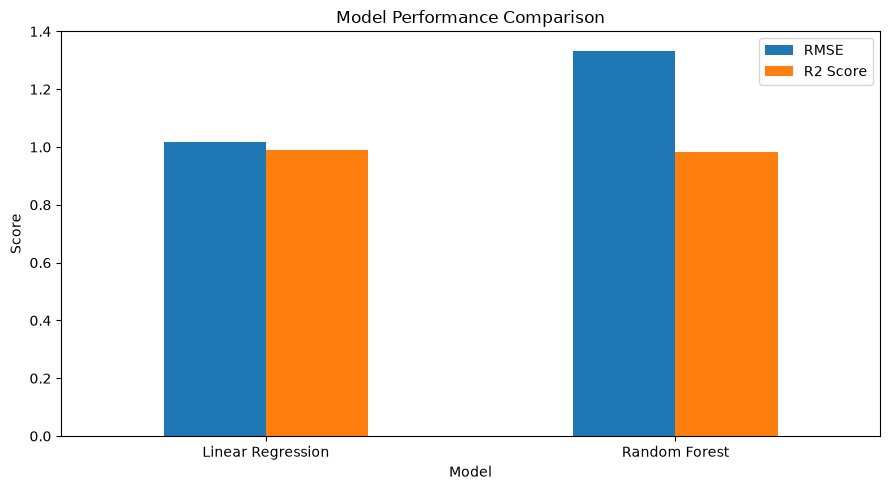

In [13]:
model_comparison.set_index("Model")[["RMSE", "R2 Score"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

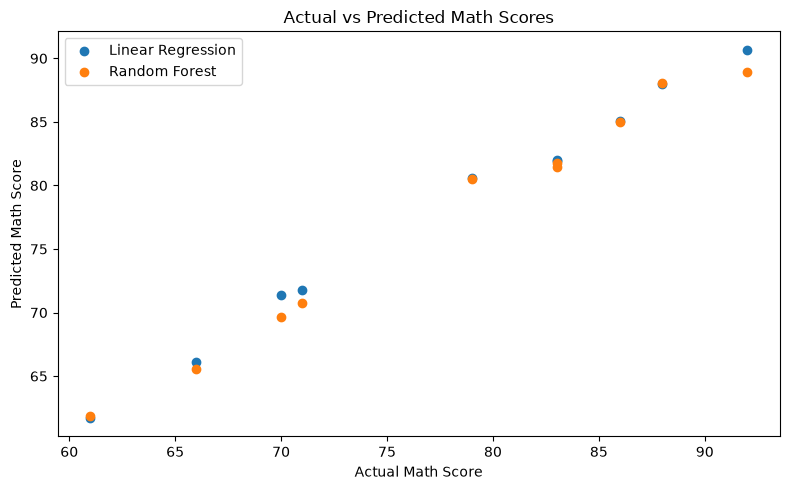

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    linear_predictions,
    label="Linear Regression"
)

plt.scatter(
    y_test,
    random_forest_predictions,
    label="Random Forest"
)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Scores")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
model_comparison.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [16]:
import joblib

joblib.dump(
    linear_model,
    "linear_regression_model.pkl"
)

['linear_regression_model.pkl']

In [17]:
joblib.dump(
    random_forest_model,
    "random_forest_model.pkl"
)

print("Both models saved successfully!")

Both models saved successfully!


## Conclusion

In this project, two regression models were developed to predict student Mathematics scores.

The models used were:
1. Linear Regression
2. Random Forest Regression

The models were evaluated using MAE, MSE, RMSE and R² Score.

The model comparison helps identify which algorithm provides better prediction performance on the test dataset.

The results show how machine learning can be applied to student performance prediction using academic and demographic features.